In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import IsolationForest

In [2]:
dataset = pd.read_csv('/content/Housing.csv')

In [3]:
dataset

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [4]:
dataset.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
dataset.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


<Axes: >

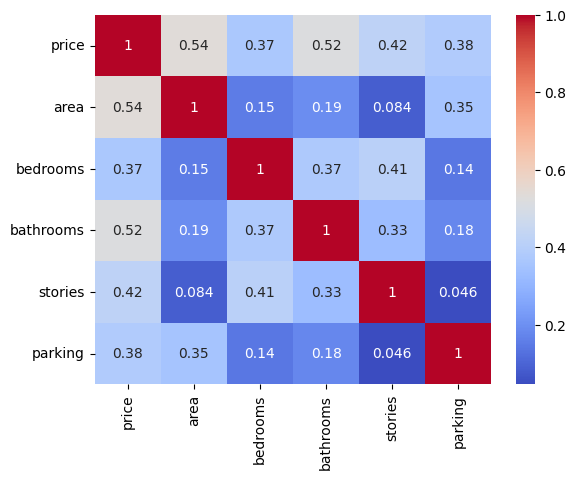

In [7]:
sns.heatmap(dataset.corr(numeric_only=True), annot = True, cbar = True, cmap = 'coolwarm')

In [10]:
dataset

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [11]:
dataset.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [16]:
dataset.furnishingstatus.unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [23]:
one_hot_columns = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
ordinal_encode_columns = ['furnishingstatus']
furnish_order = ['unfurnished', 'semi-furnished', 'furnished']

['unfurnished', 'semi-furnished', 'furnished']


In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(drop = 'if_binary'), one_hot_columns),
        ('ordinal_encode', OrdinalEncoder(categories=[furnish_order]), ordinal_encode_columns)
    ],
    remainder='passthrough'
)

In [25]:
new_dataset = preprocessor.fit_transform(dataset)
new_dataset

array([[1., 0., 0., ..., 2., 3., 2.],
       [1., 0., 0., ..., 4., 4., 3.],
       [1., 0., 1., ..., 2., 2., 2.],
       ...,
       [1., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [1., 0., 0., ..., 1., 2., 0.]])

In [27]:
col_names = preprocessor.get_feature_names_out()
col_names = [name.split('__')[-1] for name in col_names]
col_names

['mainroad_yes',
 'guestroom_yes',
 'basement_yes',
 'hotwaterheating_yes',
 'airconditioning_yes',
 'prefarea_yes',
 'furnishingstatus',
 'price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'parking']

In [28]:
transformed_dataset = pd.DataFrame(new_dataset, columns = col_names)

In [29]:
transformed_dataset

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus,price,area,bedrooms,bathrooms,stories,parking
0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,13300000.0,7420.0,4.0,2.0,3.0,2.0
1,1.0,0.0,0.0,0.0,1.0,0.0,2.0,12250000.0,8960.0,4.0,4.0,4.0,3.0
2,1.0,0.0,1.0,0.0,0.0,1.0,1.0,12250000.0,9960.0,3.0,2.0,2.0,2.0
3,1.0,0.0,1.0,0.0,1.0,1.0,2.0,12215000.0,7500.0,4.0,2.0,2.0,3.0
4,1.0,1.0,1.0,0.0,1.0,0.0,2.0,11410000.0,7420.0,4.0,1.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1820000.0,3000.0,2.0,1.0,1.0,2.0
541,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1767150.0,2400.0,3.0,1.0,1.0,0.0
542,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1750000.0,3620.0,2.0,1.0,1.0,0.0
543,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1750000.0,2910.0,3.0,1.0,1.0,0.0


<Axes: >

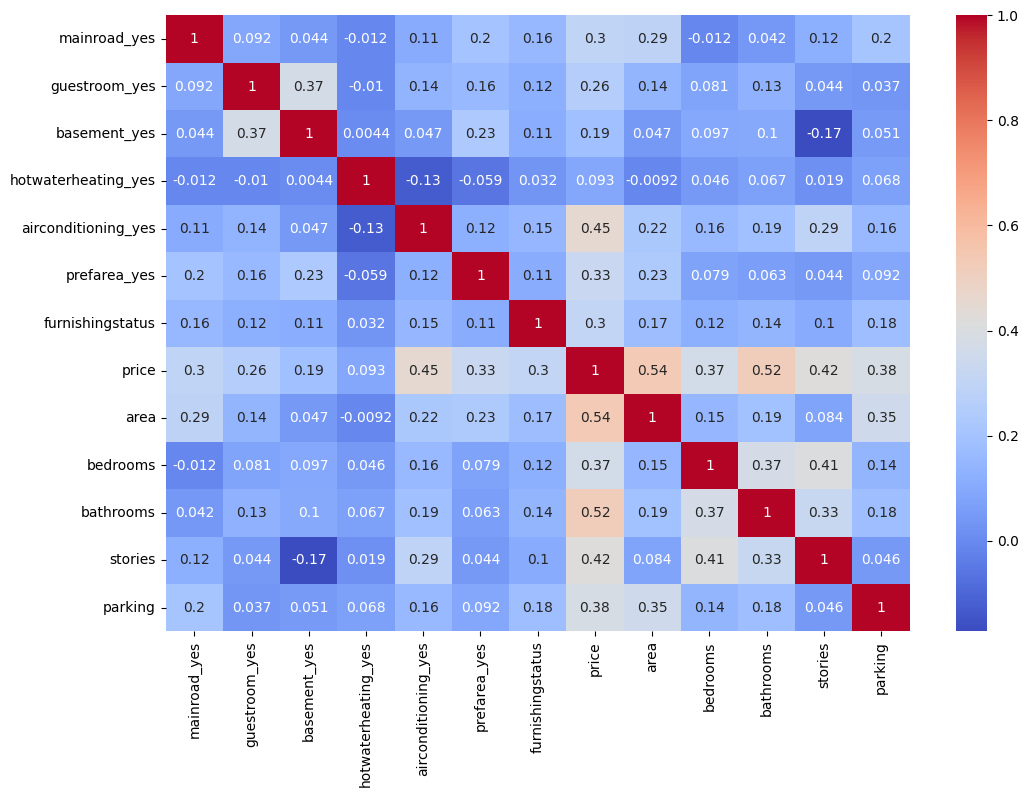

In [37]:
fig, ax = plt.subplots(figsize=(12,8))

sns.heatmap(transformed_dataset.corr(), cbar = True, cmap = 'coolwarm', annot = True)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'price'),
  Text(1, 0, 'area'),
  Text(2, 0, 'bathrooms'),
  Text(3, 0, 'airconditioning_yes'),
  Text(4, 0, 'stories'),
  Text(5, 0, 'parking'),
  Text(6, 0, 'bedrooms'),
  Text(7, 0, 'prefarea_yes'),
  Text(8, 0, 'furnishingstatus'),
  Text(9, 0, 'mainroad_yes'),
  Text(10, 0, 'guestroom_yes'),
  Text(11, 0, 'basement_yes'),
  Text(12, 0, 'hotwaterheating_yes')])

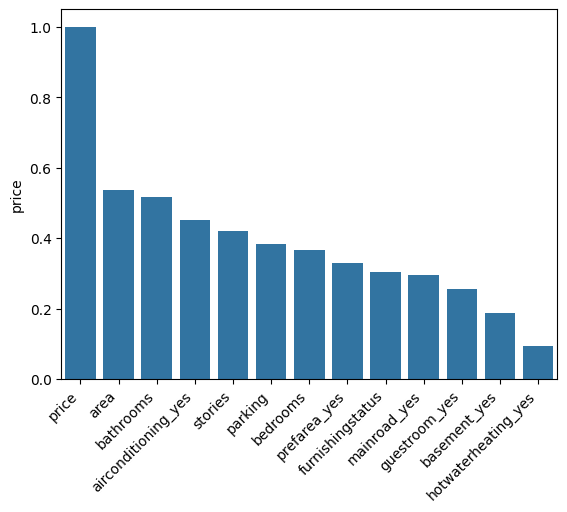

In [49]:
sns.barplot(transformed_dataset.corr().price.sort_values(ascending = False))
plt.xticks(rotation = 45, ha = 'right')

# columns: area, bathrooms, airconditioning_yes, stories, parking, bedrooms, prefarea, furnishing and mainroad give the most contribution towards price

<Axes: xlabel='area', ylabel='price'>

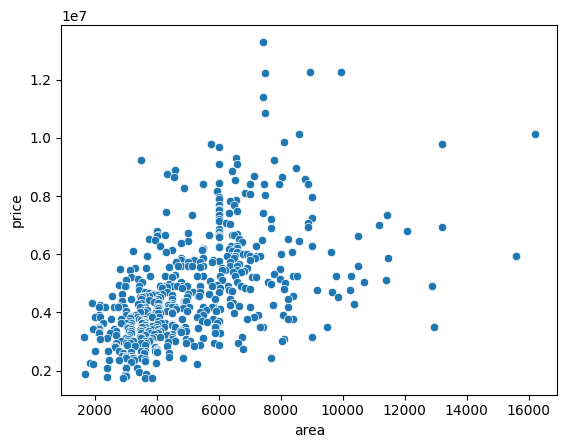

In [73]:
sns.scatterplot(transformed_dataset, x = 'area', y = 'price')

<Axes: xlabel='price'>

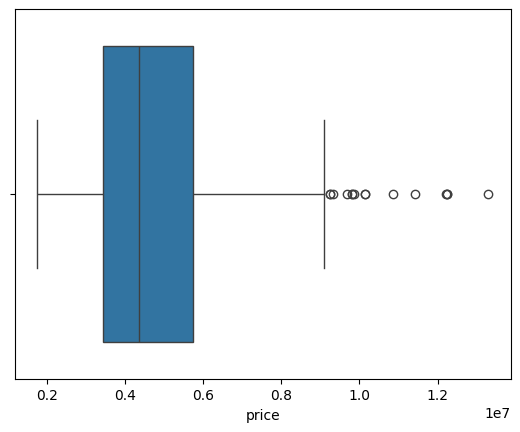

In [74]:
sns.boxplot(x = transformed_dataset.price)

<Axes: xlabel='area'>

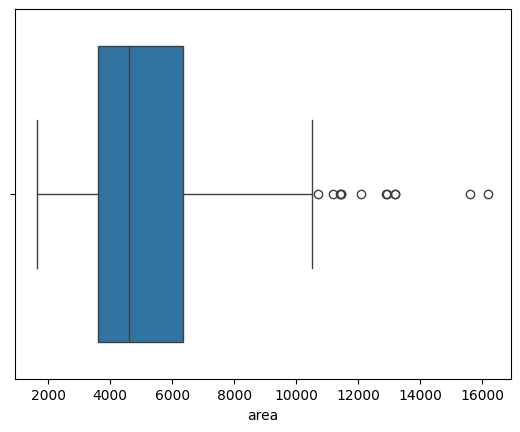

In [75]:
sns.boxplot(x = transformed_dataset.area)

In [116]:
x = transformed_dataset.drop(['price'], axis = 1)
y = transformed_dataset.price

In [118]:
models = [
    ('linearReg', LinearRegression()),
    ('Randomforest', RandomForestRegressor(n_estimators=200)),
    ('DecisionTree', DecisionTreeRegressor()),
    ('SVR', SVR()),
    ('XGBreg', XGBRegressor()),
    ('gradientboost', GradientBoostingRegressor(n_estimators=200, learning_rate = 0.1, max_depth = 4))
]

In [119]:
results = []
for name, model in models:
  trained_model = Pipeline(steps=[
      ('scalar', StandardScaler()),
      (name, model)
  ])

  scores = cross_val_score(trained_model, x, y, cv = 5, scoring='r2')

  results.append({
      'Model_name' : name,
      'Mean_accuracy' : scores.mean(),
      'std_dev' : scores.std()
  })
result_dataset = pd.DataFrame(results)


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
     

In [72]:
result_dataset.sort_values(by = 'Mean_accuracy', ascending=False)

,Model_name,Mean_accuracy,std_dev
0,linearReg,0.669402,0.059048
3,SVR,0.637821,0.041260
1,Randomforest,0.630083,0.047486
5,gradientboost,0.618131,0.042981
4,XGBreg,0.578749,0.034479
2,DecisionTree,0.251218,0.104581
